# Manual Inference & Evaluation — CustomHybridModel

Load a trained CustomHybridModel checkpoint, run inference on the Imagenette validation set, and inspect per-class accuracy with a confusion matrix.

**Change `RUN` below to switch between training runs.**

In [3]:
# ── Cell 1: Load Model ──────────────────────────────────────────────
# Change this variable to switch which training run to evaluate.

RUN = 3  # <-- change to 1, 2, 3, 4, 5, or 6

# -------------------------------------------------------------------
import sys
from pathlib import Path

THIS_DIR = Path().resolve()  # vgg_training/
sys.path.insert(0, str(THIS_DIR.parent.parent))

import torch
from fixed_io_nodes.main import load_config
from fixed_io_nodes.native.checkpoint import load_full_model
from fixed_io_nodes.vgg_training.training import CustomHybridModel

config_path = THIS_DIR / "training_runs" / f"run{RUN}" / "config.yaml"
cfg = load_config(str(config_path))
device = cfg.get("system", {}).get("device", "cpu")

model = CustomHybridModel(cfg).to(device)

weights_path = THIS_DIR / cfg["system"]["weights_save_path"]
load_full_model(model, str(weights_path), map_location=device)
model.eval()

# Disable stochastic radiation scattering for deterministic inference.
# set_training_progress with step >= total ensures scattering_prob = 0.
model.gnn.set_training_progress(1, 1)

print(f"Loaded run{RUN} from {weights_path}")
print(f"Device: {device}")

Loaded run3 from /Volumes/T9/IndraAstra/sudarshan/word-tree/fixed_io_nodes/vgg_training/training_runs/run3/run3_weights.pt
Device: mps


In [19]:
# ── Cell 2: Load Validation Dataset ─────────────────────────────────
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader, TensorDataset

DATA_DIR = THIS_DIR / "data"

# VGG16 features + soft-target labels
val = torch.load(str(DATA_DIR / "imagenette_val_data.pt"), map_location="cpu")
x_val = val["data"]   # [N, 25088]
y_val = val["label"]  # [N, 10]  (soft distribution from VGG16 classifier)

# Ground-truth integer labels from the Imagenette dataset
imagenette_dataset = torchvision.datasets.Imagenette(
    root=str(DATA_DIR),
    split="val",
    size="320px",
    download=False,
    transform=transforms.ToTensor(),
)
true_labels = torch.tensor([imagenette_dataset[i][1] for i in range(len(imagenette_dataset))])

val_loader = DataLoader(TensorDataset(x_val, true_labels), batch_size=32, shuffle=False)

print(f"Validation samples : {len(x_val)}")
print(f"Feature shape      : {x_val.shape}")
print(f"Num classes        : 10")

Validation samples : 3925
Feature shape      : torch.Size([3925, 25088])
Num classes        : 10


Overall Accuracy: 81.30%

Class                   Correct    Total   Accuracy
----------------------------------------------------
tench                       328      387     84.75%
English springer            363      395     91.90%
cassette player             301      357     84.31%
chain saw                   236      386     61.14%
church                      371      409     90.71%
French horn                 317      394     80.46%
garbage truck               331      389     85.09%
gas pump                    271      419     64.68%
golf ball                   333      399     83.46%
parachute                   340      390     87.18%


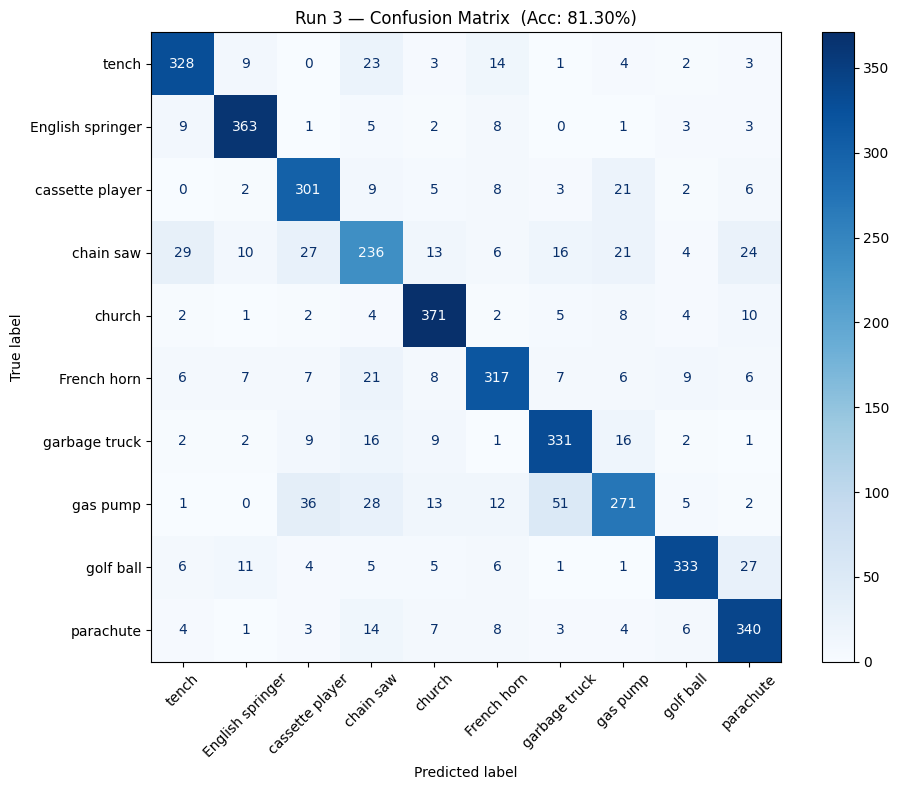

In [20]:
# ── Cell 3: Inference, Confusion Matrix & Per-Class Accuracy ────────
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

IMAGENETTE_CLASSES = [
    "tench", "English springer", "cassette player", "chain saw",
    "church", "French horn", "garbage truck", "gas pump",
    "golf ball", "parachute",
]

all_preds = []
all_true = []

with torch.no_grad():
    for x, y_true in val_loader:
        x = x.to(device)
        logits = model(x)
        preds = logits.argmax(dim=1).cpu()
        all_preds.append(preds)
        all_true.append(y_true)

all_preds = torch.cat(all_preds).numpy()
all_true = torch.cat(all_true).numpy()

# Overall accuracy
overall_acc = 100.0 * (all_preds == all_true).sum() / len(all_true)
print(f"Overall Accuracy: {overall_acc:.2f}%\n")

# Per-class accuracy
print(f"{'Class':<22} {'Correct':>8} {'Total':>8} {'Accuracy':>10}")
print("-" * 52)
for i, cls_name in enumerate(IMAGENETTE_CLASSES):
    mask = all_true == i
    cls_total = mask.sum()
    cls_correct = ((all_preds == i) & mask).sum()
    cls_acc = 100.0 * cls_correct / cls_total if cls_total > 0 else 0.0
    print(f"{cls_name:<22} {cls_correct:>8} {cls_total:>8} {cls_acc:>9.2f}%")

# Confusion matrix
cm = confusion_matrix(all_true, all_preds, labels=list(range(10)))
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=IMAGENETTE_CLASSES)
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, values_format="d")
ax.set_title(f"Run {RUN} — Confusion Matrix  (Acc: {overall_acc:.2f}%)")
plt.tight_layout()
plt.show()

In [4]:
# ── Cell 4: FLOPs Comparison — CustomHybridModel vs VGG16 MLP ──────
# Assumes `model` is already loaded from Cell 1.
#
# Uses torch.utils.flop_counter.FlopCounterMode which hooks at the ATen
# operator level — captures EVERY flop (matmul, bmm, addmm, mul, etc.)
# including custom GNN message-passing ops.

from torch.utils.flop_counter import FlopCounterMode
from torchvision.models import vgg16, VGG16_Weights

# ── Our CustomHybridModel ──
dummy_input_ours = torch.randn(1, 512 * 7 * 7, device=device)
with FlopCounterMode(display=True) as fc_ours:
    with torch.no_grad():
        model(dummy_input_ours)
flops_ours = fc_ours.get_total_flops()
params_ours = sum(p.numel() for p in model.parameters())

# ── VGG16 Classifier (MLP head only) ──
vgg = vgg16(weights=VGG16_Weights.IMAGENET1K_V1)
vgg_classifier = vgg.classifier
vgg_classifier.eval()

dummy_input_vgg = torch.randn(1, 25088)
with FlopCounterMode(display=False) as fc_vgg:
    with torch.no_grad():
        vgg_classifier(dummy_input_vgg)
flops_vgg = fc_vgg.get_total_flops()
params_vgg = sum(p.numel() for p in vgg_classifier.parameters())

# ── Print comparison ──
def fmt(n):
    if n >= 1e9:
        return f"{n / 1e9:.2f} G"
    if n >= 1e6:
        return f"{n / 1e6:.2f} M"
    if n >= 1e3:
        return f"{n / 1e3:.2f} K"
    return f"{n:.0f}"

print(f"{'Model':<30} {'FLOPs':>12} {'Params':>12}")
print("-" * 56)
print(f"{'CustomHybridModel (ours)':<30} {fmt(flops_ours):>12} {fmt(params_ours):>12}")
print(f"{'VGG16 Classifier (MLP)':<30} {fmt(flops_vgg):>12} {fmt(params_vgg):>12}")
print()
print(f"FLOPs ratio (VGG MLP / ours): {flops_vgg / flops_ours:.2f}x")
print(f"Param ratio (VGG MLP / ours): {params_vgg / params_ours:.2f}x")

Module                    FLOP    % Total
----------------------  ------  ---------
CustomHybridModel         5120    100.00%
 - aten.addmm             5120    100.00%
 CustomHybridModel.out    5120    100.00%
  - aten.addmm            5120    100.00%
Model                                 FLOPs       Params
--------------------------------------------------------
CustomHybridModel (ours)             5.12 K     249.85 K
VGG16 Classifier (MLP)             247.27 M     123.64 M

FLOPs ratio (VGG MLP / ours): 48294.40x
Param ratio (VGG MLP / ours): 494.87x
